## General Equilibrium Dynamics via Jacobians

This notebook builds towards the method introduced by Rognlie and others to solve for general equilibrium dynamics via sequence space Jacobians.

### Basic Idea

Thinking more systematically about what ad-hoc iteration procedures to solve for transition paths are doing we see that we are essentially trying to solve for a $T \times T$ system of nonlinear equations. For example, a $T$-length path for the interest rate such that a certain $T$-length path for assets is obtained.

There are smarter ways to do this than the ad-hoc iteration the literature has employed until now. For example, Newton's method. But the problem is we need a $T \times T$ Jacobian telling us how aggregate assets at each point in time respond to interest rates at each point in time. 

The trick that Rognlie and coauthors come up with is how to compute this Jacobian efficiently. First we will see how just using the Jacobian can give us a much more robust way to solve for the transition. 

### Setup
We will solve for the path of interest rates following an increase in government bonds. 

In [1]:
include("../src/incomplete_marketsGE.jl"); #loads module with relevant functions

In [5]:
# function to get the β we want - see incomplete_markets notebook
using QuantEcon
function ss_ge_calibrate(a, y, Π, up, up_inv, B, r)
    
    function assetMC(β)
        ss(a, (1-r*B)*y, r, Π, up, up_inv, Params(β = β), verbose = false)[5] - B
    end
    β = brent(assetMC, 0.8, 1/(1+r)-0.004)
    c, a₊, D, C, A = ss(a, (1-r*B)*y, r, Π, up, up_inv, p::Params; verbose = false)
    return β
end    

ss_ge_calibrate (generic function with 1 method)

In [6]:
# first solve for steady state - 
a = geomspace(0., 200., 500)
p = Params()
y, pr, Π = markov_rouwenhorst(p.ρ, p.σ, N=7);
up(c) = 1 ./ c
up_inv(c) = 1 ./ c

r = 0.01/4
B = 3
y_aftertax = (1-r*B).*y;

β_star = ss_ge_calibrate(a, y, Π, up, up_inv, B, r)
c, a₊, D, C, A = ss(a, y_aftertax, r, Π, up, up_inv, Params(β = β_star); verbose = false);


Now lets define a function to compute transition dynamics:

In [26]:
# Partial equilibrium dynamics
function td_pe(rs = nothing, ys = nothing)
    if ! isnothing(rs)
        T = length(rs)
    elseif ! isnothing(ys)
        T = size(ys)[1]
    end
    if isnothing(rs)
        rs = fill(r, T)
    end
    if isnothing(ys)
        ys = fill(y, T)
    end
    
    cs, a₊s, Ds = [Array{Float64}(undef, T, length(a), length(y)) for _ in 1:3]

    for t in reverse(1:T)
        if t == T
            c₊ = c
        else
            c₊ = cs[t+1,:,:]
        end
        if t == 1
            rlag = r
        else
            rlag = rs[t-1]
        end
        cs[t, :, :], a₊s[t, :, :] = backward_iterate(c₊, a, ys[t, :], rs[t], rlag, Π, up, up_inv, Params(β = β_star))
    end

    Ds[1, :, :] = D
    for t in 1:T-1
        a₊i = Array{Int64}(undef, length(a), length(y))
        pi_a = Array{Float64}(undef, length(a), length(y))
        for i in 1:length(y)
            a₊i[:, i], pi_a[:, i] = interpolate_policy(a, a₊s[t, :, i])
        end
        Ds[t+1, :, :] = forward_iterate(Ds[t, :, :], Π, a₊i, pi_a)

    end

    # return aggregate paths
    return sum(Ds.*cs, dims = (2, 3)), sum(Ds.*a₊s, dims = (2, 3))

end

td_pe (generic function with 3 methods)

#### Path for government bonds

In [57]:
B = 3. # ss value of bonds
T = 200
Bs = B .+ 0.01 * exp.(-0.5 * (0:T-1)) .* (0:T-1).^2;

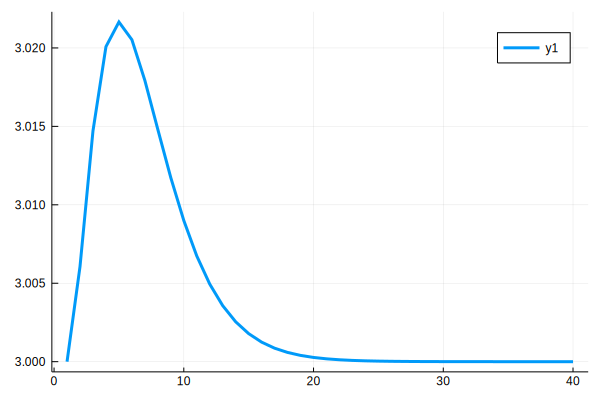

In [58]:
using Plots
plot(Bs[1:40], lw = 3)

#### Map from r to after-tax household incomes

Note that after-tax household incomes - or disposable incomes - are dependent on the paths for real interest rates and the path for government bonds via the government's budget constraint. To deal with this, we make income explicitly a function of the paths as follows:

In [59]:
function y_d(rs, Bs)
    rlag = vcat(r, rs[1:end-1])
    Blag = vcat(B, Bs[1:end-1])
    
    netcost = (1 .+ rlag) .* Blag .- Bs  # what govt has to pay at time t
    netcost_ss = r*B             # what govt has to pay in ss
    
    return ((1 .- netcost) ./ (1 - netcost_ss)) .* y_aftertax'
end;

To understand what we just did, plot path after-tax income assuming we are at steady state real interest rate:

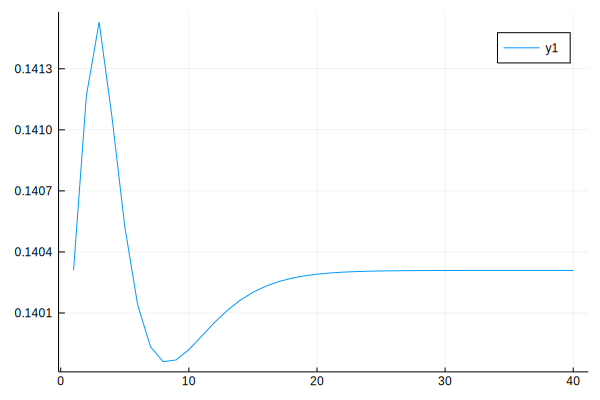

In [60]:
plot(y_d(fill(r,T), Bs)[1:40,1])

By doing this we avoid having to code explicitly how the incomes depend on the interst rate when doing the transition code.

### Building the Jacobian - Naive approach

We will run a partial equilibrium computation for $T$ times in response to an interest rate shock at each $t$ and compute how assets at each point in time to build the Jacobian. Since we are only interested in the response to $r$ we will live government bonds at their steady state level. However, we do have to change the incomes since the interest rate does affect this. This is easy given the function we defined above. 

In [72]:
ϵ = 1E-3 # shock
J = zeros(T,T)

for t in 1:T
    r_shock = r .+ ϵ * ((1:T) .== t)  # shock at time t
    y_shock = y_d(r_shock, fill(B, T))
    J[:, t] = (td_pe(r_shock, y_shock)[2] .- B) ./ ϵ
end

With the Jacobian in hand, now lets solve the path for the interest rate, at each point updating in the direction suggested by Jacobian:

In [84]:
rs = fill(r, T)
for it in 1:500
    ys = y_d(rs, Bs)
    MC_error = td_pe(rs, ys)[2] .- Bs 
    abs_error = norm(MC_error, Inf)
    
    if mod(it, 10) == 0 
        println("error on iteration $it is $abs_error")
    end
    
    if abs_error < 1E-8
        println("it took $it iterations to converge")
        break
    end
    
    rs = rs - (J\MC_error[:])
end

it took 5 iterations to converge


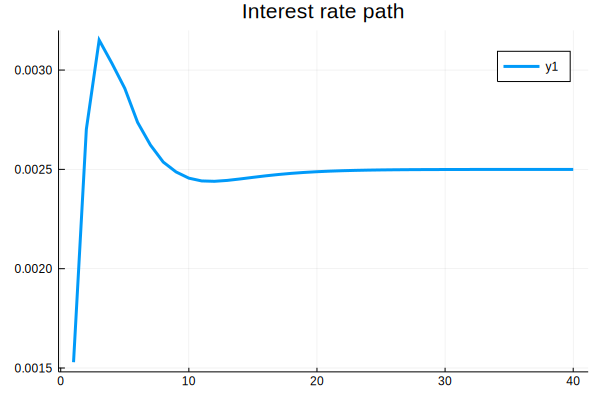

In [85]:
plot(rs[1:40], lw =3, title = "Interest rate path")

## Improving the Algorithm

### Step 1: Avoid redundant policy function calculations

Note that the policy function at $t=10$ to a $t=20$ interest rate shock is tha same as the policy function at $t=0$ to a $t=10$ interest rate shock - in both cases we need to do 10 backward iterations. 

$\implies$ we could calculate all of these once in response to an interest rate shock, then recombine.